# Mathematically-Sized Full-Delta Basket -- Sandbox

**Nitesh's guidance (email):** "Calculate the basket of options mathematically and get
closer to the LETF's delta. Don't guess the option volume. For ATM options the required
volume should come closer to 4x; further OTM will have lower delta so more volume is
needed. The cost may be prohibitive, but we need to try."

## The Math

Current 1/N basket: each leg targets `TSLL_LEVER * cum_tsll / N_legs` of dollar-delta.  
Total at inception = 1× LETF delta. Correct at t=0, but collapses intra-cycle when OTM
legs lose delta.

**This notebook:** every leg independently targets the **full** LETF dollar-delta:
```
n_per_leg = (TSLL_LEVER × cum_tsll) / (delta_leg × 100 × S)
```
Total at inception = N × LETF delta (N-times over-hedged). After a 20% crash the
surviving legs still collectively cover most of the exposure, at the cost of N× premium.

ATM (delta≈0.5): `2.0/0.5 = 4` options per covered share-equivalent → Nitesh's "4×".  
10%OTM (delta≈0.25): 8×.  20%OTM (delta≈0.15): ~13×.

**Same CBA logic as `itm_basket_cba_sandbox.ipynb`** (cheapest of TSLA or TSLL per leg).
**Same compositions.** Ranked by Max DD. Premium/yr column added.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls, load_tsll_calls
from options_selection import select_contract, bs_delta, MONEYNESS_RANGES
from metrics import summarize
from cba_backtest import _position_cost

# Add ITM buckets locally -- no production files touched
MONEYNESS_RANGES["10% ITM"] = (0.85, 0.95)
MONEYNESS_RANGES["20% ITM"] = (0.75, 0.85)

%matplotlib inline

tsll_df    = load_tsll()
r_tsll     = tsll_df.set_index("Date")["Close"].pct_change().dropna()
returns    = r_tsll.rename("TSLL").to_frame()

tsla_spot  = load_tsla_underlying().set_index("Date")["Close"].reindex(returns.index).ffill()
tsll_spot  = tsll_df.set_index("Date")["Close"].reindex(returns.index).ffill()

tsla_calls = load_tsla_calls()
tsll_calls = load_tsll_calls()

tsla_lut   = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
tsll_lut   = tsll_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

tsla_sigma = (tsla_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()
tsll_sigma = (tsll_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()

n_years = len(returns) / 252

print(f"{len(returns):,} trading days  {returns.index.min().date()} -> {returns.index.max().date()}")
print(f"Simulation span: {n_years:.2f} years")
print("Data loaded.")

962 trading days  2022-08-10 -> 2026-06-10
Simulation span: 3.82 years
Data loaded.


In [2]:
TARGET_DTE = 90
MAX_DTE    = 110
ROLL_DTE   = 5
TSLL_LEVER = 2.0
R_RF       = 0.05

FALLBACK = {
    "20% ITM": ["10% ITM", "ATM"],
    "10% ITM": ["ATM"],
    "ATM":     ["10% OTM"],
    "10% OTM": ["ATM"],
    "20% OTM": ["10% OTM", "ATM"],
}

COMPOSITIONS = {
    "Baseline (single 10%OTM, CBA)": ["10% OTM"],
    "A: ATM+10%OTM+20%OTM":          ["ATM", "10% OTM", "20% OTM"],
    "B: 10%ITM+ATM+10%OTM":          ["10% ITM", "ATM", "10% OTM"],
    "C: 10%ITM+ATM+10%OTM+20%OTM":  ["10% ITM", "ATM", "10% OTM", "20% OTM"],
    "D: 10%ITM+10%OTM+20%OTM":      ["10% ITM", "10% OTM", "20% OTM"],
    "E: 20%ITM+10%ITM+ATM+10%OTM":  ["20% ITM", "10% ITM", "ATM", "10% OTM"],
    "F: 20%ITM+10%ITM+ATM":         ["20% ITM", "10% ITM", "ATM"],
}

print(f"target_dte={TARGET_DTE}  roll_dte={ROLL_DTE}  frictionless")
print(f"SIZING: full LETF delta per leg (NO /n_legs) -- Nitesh's mathematical approach")
print(f"{len(COMPOSITIONS)} compositions")

target_dte=90  roll_dte=5  frictionless
SIZING: full LETF delta per leg (NO /n_legs) -- Nitesh's mathematical approach
7 compositions


In [3]:
def _cba_leg(d, bucket, cum_val):
    """
    For one basket leg, try both TSLA and TSLL (and their fallback chains).
    cum_val is the FULL LETF notional target -- NOT pre-divided by n_legs.
    Return the cheapest position dict, or None.
    """
    sig_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
    sig_b = float(tsll_sigma.loc[d]) if d in tsll_sigma.index else 0.5

    best_cost = float("inf")
    best_pos  = None

    for bucket_try in [bucket] + FALLBACK.get(bucket, []):
        row_a = select_contract(tsla_calls, tsla_spot, d, bucket_try, TARGET_DTE, max_dte=MAX_DTE)
        cost_a, n_a, entry_a = _position_cost(row_a, tsla_spot.loc[d], sig_a, TSLL_LEVER, cum_val, d)
        if row_a is not None and cost_a < best_cost:
            best_cost = cost_a
            best_pos  = {"ul": "tsla", "raw_id": row_a["raw_id"],
                         "strike": float(row_a["strike"]), "expiry": row_a["expiry"],
                         "n": n_a, "price": entry_a}

        row_b = select_contract(tsll_calls, tsll_spot, d, bucket_try, TARGET_DTE, max_dte=MAX_DTE)
        cost_b, n_b, entry_b = _position_cost(row_b, tsll_spot.loc[d], sig_b, 1.0, cum_val, d)
        if row_b is not None and cost_b < best_cost:
            best_cost = cost_b
            best_pos  = {"ul": "tsll", "raw_id": row_b["raw_id"],
                         "strike": float(row_b["strike"]), "expiry": row_b["expiry"],
                         "n": n_b, "price": entry_b}

        if best_pos is not None:
            break

    return best_pos


def simulate_basket_full_delta(returns, basket_buckets):
    """
    Short $1 TSLL + simultaneous basket of calls.

    KEY DIFFERENCE from itm_basket_cba_sandbox:
    Each leg is sized to the FULL LETF dollar-delta (not 1/N_legs).
    At inception total hedge = N * LETF_delta (N-times over-hedged).
    Cost is proportionally higher; MaxDD should be significantly lower.

    Returns: (equity, n_misses, tsll_fills, tsla_fills, total_premium_paid)
    """
    n_legs        = len(basket_buckets)
    cum_tsll      = (1 + returns["TSLL"]).cumprod()
    base_equity   = 2.0 - cum_tsll

    equity        = pd.Series(index=returns.index, dtype=float)
    positions     = {b: None for b in basket_buckets}
    option_pnl    = 0.0
    premium_paid  = 0.0   # cumulative option premium spent (dollar-notional basis)
    n_misses      = 0
    tsll_fills    = 0
    tsla_fills    = 0

    def mtm(pos, d):
        lut  = tsla_lut if pos["ul"] == "tsla" else tsll_lut
        spot = tsla_spot if pos["ul"] == "tsla" else tsll_spot
        if d > pos["expiry"]:
            return max(float(spot.loc[d]) - pos["strike"], 0.0)
        px = lut.get((pos["raw_id"], d))
        return float(px) if (px is not None and not pd.isna(px)) else pos["price"]

    for d in returns.index:
        held_dtes = [(positions[b]["expiry"] - d).days
                     if positions[b] is not None else -1
                     for b in basket_buckets]
        need_roll = any(positions[b] is None for b in basket_buckets) \
                    or min(held_dtes) < ROLL_DTE

        if need_roll:
            # close all existing legs
            for b in basket_buckets:
                if positions[b] is not None:
                    option_pnl += positions[b]["n"] * 100 * (
                        mtm(positions[b], d) - positions[b]["price"])

            # open new legs -- FULL cum_val per leg (Nitesh's math)
            cum_val = float(cum_tsll.loc[d])
            new_positions = {}
            for b in basket_buckets:
                pos = _cba_leg(d, b, cum_val)   # <-- FULL target, no /n_legs
                if pos is None:
                    n_misses += 1
                else:
                    premium_paid += pos["n"] * 100 * pos["price"]
                    if pos["ul"] == "tsll": tsll_fills += 1
                    else:                   tsla_fills += 1
                new_positions[b] = pos
            positions = new_positions

        else:
            for b in basket_buckets:
                if positions[b] is not None:
                    px = mtm(positions[b], d)
                    option_pnl            += positions[b]["n"] * 100 * (px - positions[b]["price"])
                    positions[b]["price"]  = px

        equity.loc[d] = base_equity.loc[d] + option_pnl

    return equity, n_misses, tsll_fills, tsla_fills, premium_paid

In [4]:
rows   = []
curves = {}

for label, buckets in COMPOSITIONS.items():
    eq, n_miss, tsll_f, tsla_f, prem = simulate_basket_full_delta(returns, buckets)
    eq = eq / eq.iloc[0]
    assert eq.isna().sum() == 0, f"{label}: NaNs in equity"
    curves[label] = eq

    row = summarize(eq, eq.pct_change().dropna(), label)
    total_f = tsll_f + tsla_f
    row["TSLL%"]      = f"{tsll_f/total_f*100:.0f}%" if total_f else "0%"
    row["Prem/yr"]    = prem / n_years
    row["Leg misses"] = n_miss
    rows.append(row)
    print(f"{label:45s}  CAGR={row['CAGR']:+.1%}  Sharpe={row['Sharpe']:.2f}  "
          f"MaxDD={row['Max DD']:.1%}  Prem/yr=${row['Prem/yr']:.4f}  TSLL={row['TSLL%']}")

results_df = pd.DataFrame(rows).sort_values("Max DD", ascending=False)
pd.set_option("display.width", 240)
pd.set_option("display.max_columns", None)

print()
print("=== FULL-DELTA BASKET -- Ranked by Max DD (best first) ===")
print(results_df[["Strategy", "CAGR", "Sharpe", "Max DD", "Calmar",
                  "Prem/yr", "TSLL%", "Leg misses"]].to_string(index=False))

Baseline (single 10%OTM, CBA)                  CAGR=+10.0%  Sharpe=0.45  MaxDD=-33.2%  Prem/yr=$0.9917  TSLL=68%


A: ATM+10%OTM+20%OTM                           CAGR=+17.5%  Sharpe=-0.26  MaxDD=-136.5%  Prem/yr=$4.3567  TSLL=66%


B: 10%ITM+ATM+10%OTM                           CAGR=+3.1%  Sharpe=-0.12  MaxDD=-182.6%  Prem/yr=$3.4149  TSLL=72%


C: 10%ITM+ATM+10%OTM+20%OTM                    CAGR=+15.5%  Sharpe=0.12  MaxDD=-202.9%  Prem/yr=$6.7197  TSLL=70%
D: 10%ITM+10%OTM+20%OTM                        CAGR=+17.1%  Sharpe=0.71  MaxDD=-166.0%  Prem/yr=$4.7585  TSLL=65%


E: 20%ITM+10%ITM+ATM+10%OTM                    CAGR=+0.5%  Sharpe=-0.12  MaxDD=-253.6%  Prem/yr=$4.9396  TSLL=69%
F: 20%ITM+10%ITM+ATM                           CAGR=+5.5%  Sharpe=0.09  MaxDD=-209.7%  Prem/yr=$3.4713  TSLL=70%

=== FULL-DELTA BASKET -- Ranked by Max DD (best first) ===
                     Strategy     CAGR    Sharpe    Max DD   Calmar  Prem/yr TSLL%  Leg misses
Baseline (single 10%OTM, CBA) 0.099934  0.453037 -0.331802 0.301185 0.991709   68%           0
         A: ATM+10%OTM+20%OTM 0.175380 -0.259583 -1.364688 0.128513 4.356712   66%           0
      D: 10%ITM+10%OTM+20%OTM 0.170666  0.712356 -1.660034 0.102809 4.758535   65%           0
         B: 10%ITM+ATM+10%OTM 0.030591 -0.124206 -1.825809 0.016755 3.414910   72%           0
  C: 10%ITM+ATM+10%OTM+20%OTM 0.155240  0.116146 -2.028940 0.076513 6.719667   70%           0
         F: 20%ITM+10%ITM+ATM 0.055085  0.089614 -2.096668 0.026273 3.471262   70%           0
  E: 20%ITM+10%ITM+ATM+10%OTM 0.005304 -0.124087

In [5]:
# Side-by-side comparison: Full-delta (this notebook) vs 1/N CBA (prior run)
prior_1n = {
    "Baseline (single 10%OTM, CBA)": {"CAGR": 0.100, "Sharpe": 0.45, "MaxDD": -0.332},
    "A: ATM+10%OTM+20%OTM":          {"CAGR": 0.145, "Sharpe": 0.59, "MaxDD": -0.339},
    "B: 10%ITM+ATM+10%OTM":          {"CAGR": 0.098, "Sharpe": 0.46, "MaxDD": -0.340},
    "C: 10%ITM+ATM+10%OTM+20%OTM":  {"CAGR": 0.135, "Sharpe": 0.57, "MaxDD": -0.264},
    "D: 10%ITM+10%OTM+20%OTM":      {"CAGR": 0.143, "Sharpe": 0.58, "MaxDD": -0.322},
    "E: 20%ITM+10%ITM+ATM+10%OTM":  {"CAGR": 0.101, "Sharpe": 0.47, "MaxDD": -0.312},
    "F: 20%ITM+10%ITM+ATM":         {"CAGR": 0.105, "Sharpe": 0.47, "MaxDD": -0.391},
}

print(f"{'Strategy':<42}  {'1/N CAGR':>9} {'1/N MaxDD':>10}  {'Full CAGR':>10} {'Full MaxDD':>11}  {'DD Delta':>9}")
print("-" * 100)
for row in rows:
    lbl   = row["Strategy"]
    prior = prior_1n.get(lbl, {})
    if prior:
        dd_delta = row["Max DD"] - prior["MaxDD"]
        sign = "+" if dd_delta > 0 else ""
        print(f"{lbl:<42}  {prior['CAGR']:>+9.1%} {prior['MaxDD']:>+10.1%}  "
              f"{row['CAGR']:>+10.1%} {row['Max DD']:>+11.1%}  {sign}{dd_delta:.1%}")

Strategy                                     1/N CAGR  1/N MaxDD   Full CAGR  Full MaxDD   DD Delta
----------------------------------------------------------------------------------------------------
Baseline (single 10%OTM, CBA)                  +10.0%     -33.2%      +10.0%      -33.2%  +0.0%
A: ATM+10%OTM+20%OTM                           +14.5%     -33.9%      +17.5%     -136.5%  -102.6%
B: 10%ITM+ATM+10%OTM                            +9.8%     -34.0%       +3.1%     -182.6%  -148.6%
C: 10%ITM+ATM+10%OTM+20%OTM                    +13.5%     -26.4%      +15.5%     -202.9%  -176.5%
D: 10%ITM+10%OTM+20%OTM                        +14.3%     -32.2%      +17.1%     -166.0%  -133.8%
E: 20%ITM+10%ITM+ATM+10%OTM                    +10.1%     -31.2%       +0.5%     -253.6%  -222.4%
F: 20%ITM+10%ITM+ATM                           +10.5%     -39.1%       +5.5%     -209.7%  -170.6%


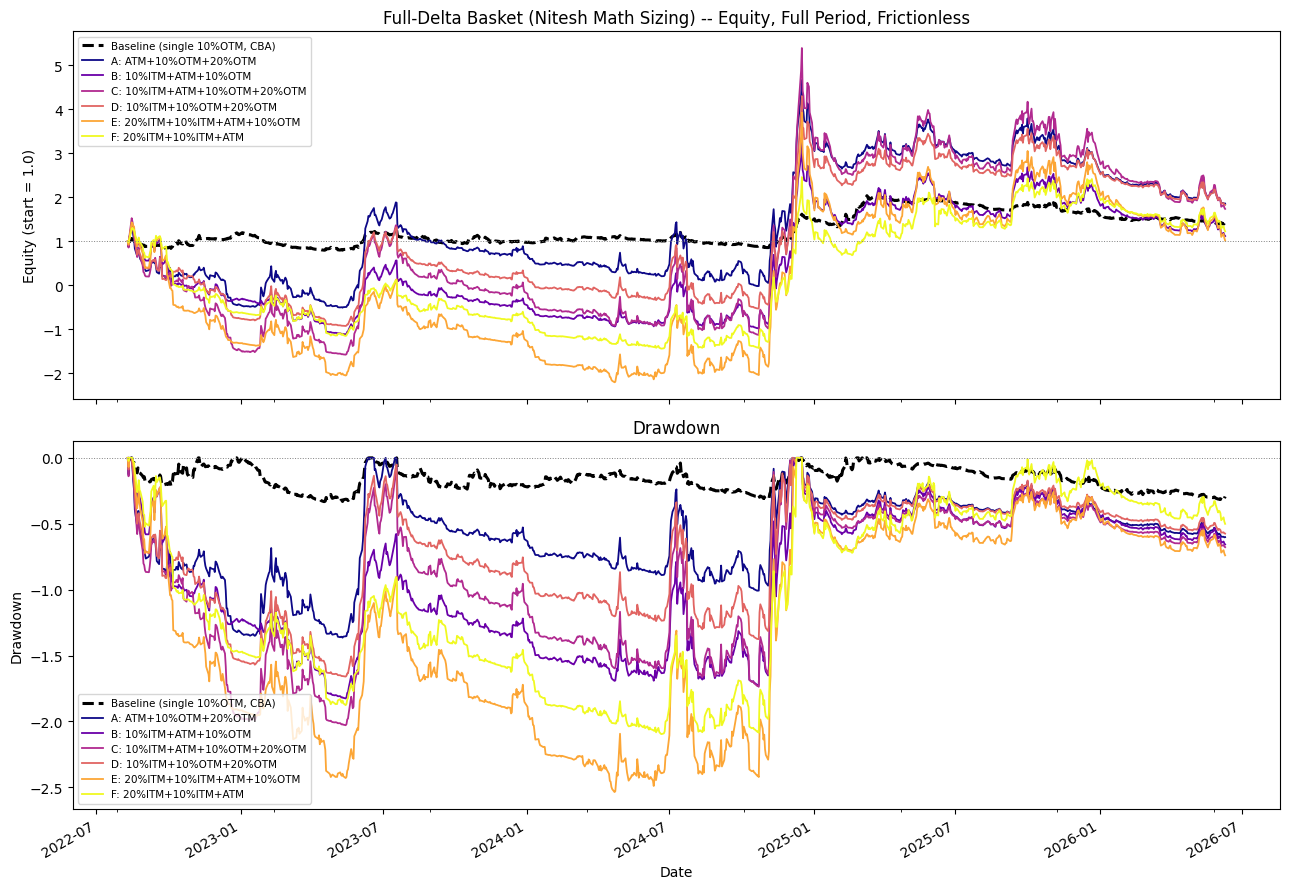

Saved: observations/strategies/sandbox/math_hedge_basket.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

non_bl = [l for l in curves if "Baseline" not in l]
colors = cm.plasma([i / max(len(non_bl)-1, 1) for i in range(len(non_bl))])

bl = "Baseline (single 10%OTM, CBA)"
curves[bl].plot(ax=axes[0], label=bl, color="black", linewidth=2.2, linestyle="--")
(curves[bl] / curves[bl].cummax() - 1).plot(ax=axes[1], label=bl, color="black",
                                              linewidth=2.2, linestyle="--")
for label, color in zip(non_bl, colors):
    curves[label].plot(ax=axes[0], label=label, color=color, linewidth=1.3)
    (curves[label] / curves[label].cummax() - 1).plot(ax=axes[1], label=label,
                                                       color=color, linewidth=1.3)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=0.7)
axes[0].set_title("Full-Delta Basket (Nitesh Math Sizing) -- Equity, Full Period, Frictionless")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend(fontsize=7.5, loc="upper left")

axes[1].axhline(0.0, color="grey", linestyle=":", linewidth=0.7)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].legend(fontsize=7.5, loc="lower left")

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "math_hedge_basket.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")